In [186]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [187]:
df = pd.DataFrame()

In [188]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [189]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

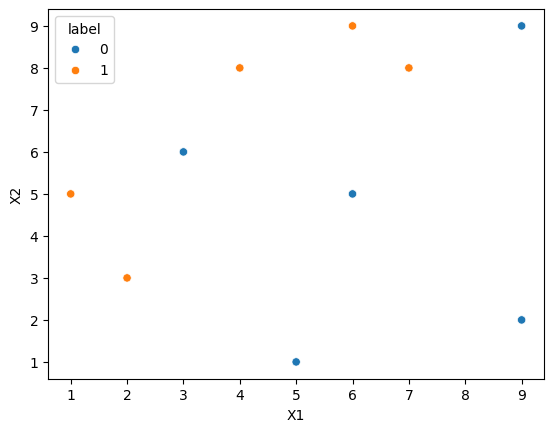

In [190]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [191]:
df['weights']=1/df.shape[0]
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [192]:
from sklearn.tree import DecisionTreeClassifier

In [193]:
df1=DecisionTreeClassifier(max_depth=1)

In [194]:
x=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [195]:
df1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

In [196]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

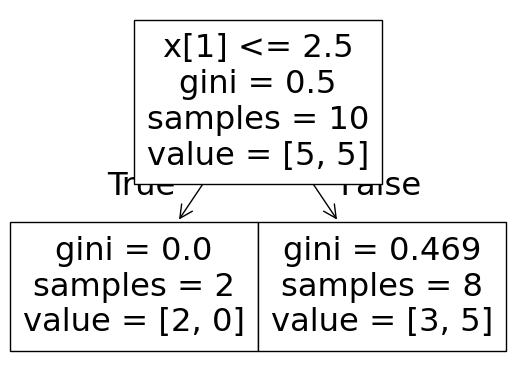

In [197]:
plot_tree(df1)

<Axes: >

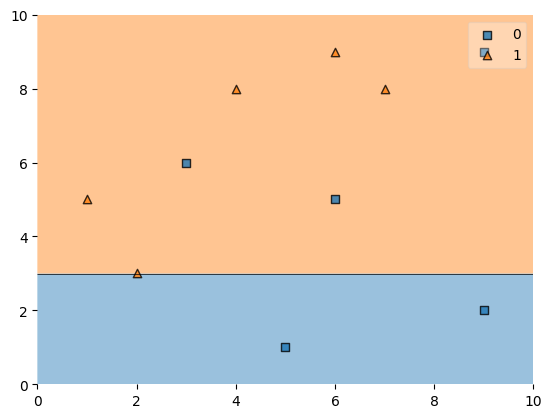

In [198]:
plot_decision_regions(x,y,df1)

In [199]:
df['y_pred']=df1.predict(x)

In [200]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [201]:
def calculate_model_weight(error):
    
    return 0.5*np.log(((1-error)/error+0.00000001))

In [202]:
#  step :3  calculate model weight 
alpha1=calculate_model_weight(0.3)
alpha1

0.42364893233645895

In [203]:
#step 4: update weights

def update_row_weight(row,alpha=0.423):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [204]:
df['updated_weights']=df.apply(update_row_weight,axis=1)

In [205]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [206]:
df['updated_weights'].sum()

0.9165153319682015

In [207]:
df['normalized_weights']=df['updated_weights']/df['updated_weights'].sum()

In [208]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [209]:
df['normalized_weights'].sum()

1.0

In [210]:
df['cumsum_upper']=np.cumsum(df['normalized_weights'])

In [211]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized_weights']

In [212]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [213]:
def create_new_datset(df):
    indices=[]
    
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [214]:
index_values=create_new_datset(df)
index_values

[3, 5, 2, 5, 2, 8, 8, 7, 8, 0]

In [215]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [216]:
second_df

,X1,X2,label,weights
3,4,8,1,0.1
5,6,9,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1
2,3,6,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1


In [217]:
df2=DecisionTreeClassifier(max_depth=1)

In [218]:
x=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [219]:
df2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

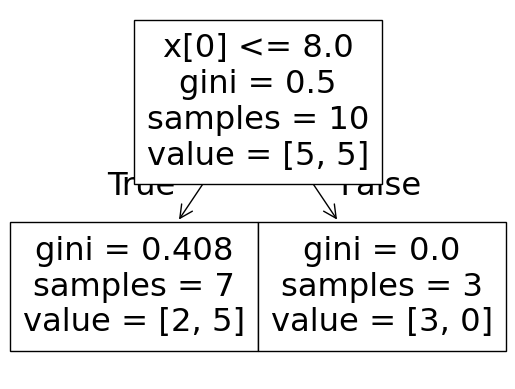

In [220]:
plot_tree(df2)

<Axes: >

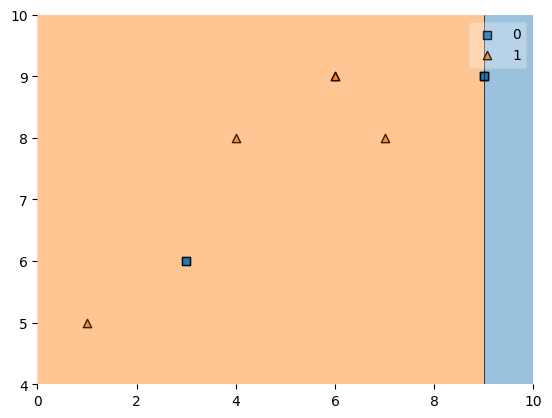

In [221]:
plot_decision_regions(x,y,df2)

In [222]:
second_df['y_pred']=df2.predict(x)

In [223]:
second_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,1
5,6,9,1,0.1,1
2,3,6,0,0.1,1
5,6,9,1,0.1,1
2,3,6,0,0.1,1
8,9,9,0,0.1,0
8,9,9,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,0
0,1,5,1,0.1,1


In [224]:
alpha2=calculate_model_weight(0.1)
alpha2

1.0986122892236654

In [225]:
def update_row_weights(row,alpha=1.09):
    if row['label']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [226]:
second_df['updated_weights']=second_df.apply(update_row_weights,axis=1)

In [227]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
3,4,8,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622
2,3,6,0,0.1,1,0.297427
5,6,9,1,0.1,1,0.033622
2,3,6,0,0.1,1,0.297427
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
0,1,5,1,0.1,1,0.033622


In [228]:
second_df['normalized_weight']=second_df['updated_weights']/second_df['updated_weights'].sum()

In [229]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weight
3,4,8,1,0.1,1,0.033622,0.038922
5,6,9,1,0.1,1,0.033622,0.038922
2,3,6,0,0.1,1,0.297427,0.344313
5,6,9,1,0.1,1,0.033622,0.038922
2,3,6,0,0.1,1,0.297427,0.344313
8,9,9,0,0.1,0,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
7,7,8,1,0.1,1,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
0,1,5,1,0.1,1,0.033622,0.038922


In [230]:
second_df['cumsum_upper']=np.cumsum(second_df['normalized_weight'])

In [231]:
second_df['cumsum_lower']=second_df['cumsum_upper']-second_df['normalized_weight']

In [232]:
second_df.columns

Index(['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights',
       'normalized_weight', 'cumsum_upper', 'cumsum_lower'],
      dtype='object')

In [233]:
second_df[['X1', 'X2', 'label', 'weights', 'y_pred','normalized_weight', 'cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weight,cumsum_lower,cumsum_upper
3,4,8,1,0.1,1,0.038922,0.000000,0.038922
5,6,9,1,0.1,1,0.038922,0.038922,0.077843
2,3,6,0,0.1,1,0.344313,0.077843,0.422157
5,6,9,1,0.1,1,0.038922,0.422157,0.461078
2,3,6,0,0.1,1,0.344313,0.461078,0.805392
8,9,9,0,0.1,0,0.038922,0.805392,0.844313
8,9,9,0,0.1,0,0.038922,0.844313,0.883235
7,7,8,1,0.1,1,0.038922,0.883235,0.922157
8,9,9,0,0.1,0,0.038922,0.922157,0.961078
0,1,5,1,0.1,1,0.038922,0.961078,1.000000


In [234]:
index_values=create_new_datset(second_df)

In [235]:
third_df=second_df.iloc[index_values,[0,1,2,3]]

In [236]:
third_df

,X1,X2,label,weights
5,6,9,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1
2,3,6,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1


In [237]:
df3=DecisionTreeClassifier(max_depth=1)

In [238]:
x=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [239]:
df3.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

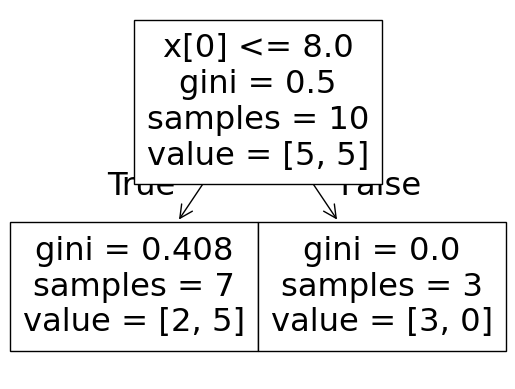

In [240]:
plot_tree(df3)

<Axes: >

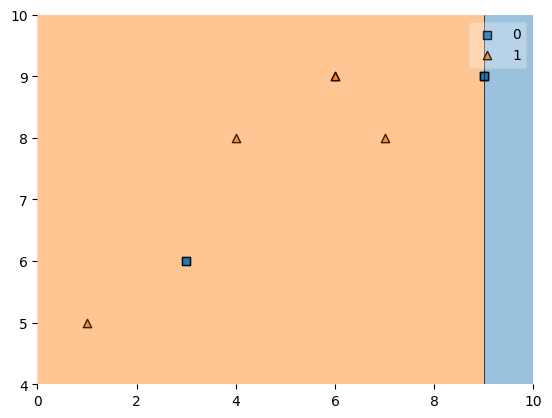

In [241]:
plot_decision_regions(x,y,df3)

In [242]:
third_df['y_pred']=df3.predict(x)

In [243]:
third_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
2,3,6,0,0.1,1
2,3,6,0,0.1,1
8,9,9,0,0.1,1
2,3,6,0,0.1,1
2,3,6,0,0.1,0
7,7,8,1,0.1,0
2,3,6,0,0.1,1
8,9,9,0,0.1,0
2,3,6,0,0.1,1


In [244]:
alpha3=calculate_model_weight(0.7)
alpha3

-0.4236489185269352

In [245]:
print(alpha1,alpha2,alpha3)

0.42364893233645895 1.0986122892236654 -0.4236489185269352


Prediction

In [246]:
query=np.array([1,5]).reshape(1,2)
df1.predict(query)

array([1], dtype=int64)

In [247]:
df2.predict(query)

array([1], dtype=int64)

In [248]:
df3.predict(query)

array([1], dtype=int64)

In [249]:
alpha1*1+alpha2*1+alpha3*1

1.0986123030331891

In [250]:
np.sign(1.09)

1.0

In [251]:
query=np.array([9,9]).reshape(1,2)
df1.predict(query)

array([1], dtype=int64)

In [252]:
df2.predict(query)

array([0], dtype=int64)

In [253]:
df3.predict(query)

array([0], dtype=int64)

In [257]:
alpha1*1+alpha2*-1+alpha3*-1

-0.25131443836027123

In [259]:
np.sign(-0.25131443836027123)

-1.0